# 01 — Data Exploration

浏览已解析的 benchmark 数据，理解 lot、operation、tool 的结构和规模。

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load parsed operations
ops = pd.read_csv('../data/processed/operations.csv')
print(f'Operations: {len(ops):,} rows')
ops.head(10)

Operations: 1,100 rows


,instance_id,lot_id,operation_seq,tool_id,run_time
0,abz5,L0001,1,T04,1.4667
1,abz5,L0001,2,T08,1.1333
2,abz5,L0001,3,T06,1.5667
3,abz5,L0001,4,T05,1.6500
4,abz5,L0001,5,T01,1.1167
5,abz5,L0001,6,T02,1.4833
6,abz5,L0001,7,T09,1.2833
7,abz5,L0001,8,T07,1.6500
8,abz5,L0001,9,T00,1.4333
9,abz5,L0001,10,T03,1.5333


In [3]:
# Load lot master data
lots = pd.read_csv('../data/processed/dim_lot.csv')
print(f'Lots: {len(lots):,} rows')
lots.head()

Lots: 80 rows


,lot_id,instance_id,release_ts,due_ts,priority,product_family
0,L0001,abz5,2025-06-01 08:00:00,2025-06-15 08:00:00,1,NAND_A
1,L0002,abz5,2025-06-01 10:00:00,2025-06-16 09:00:00,2,NAND_B
2,L0003,abz5,2025-06-01 12:00:00,2025-06-17 10:00:00,3,NAND_A
3,L0004,abz5,2025-06-01 14:00:00,2025-06-18 11:00:00,1,NAND_B
4,L0005,abz5,2025-06-01 16:00:00,2025-06-19 12:00:00,2,NAND_A


In [4]:
# Load tool master data
tools = pd.read_csv('../data/processed/dim_tool.csv')
tools

,tool_id,tool_group,tool_type,is_constraint_tool
0,T00,TG_00,LITHO,True
1,T01,TG_00,ETCH,False
2,T02,TG_00,CMP,False
3,T03,TG_01,CVD,True
4,T04,TG_01,METRO,False
5,T05,TG_01,LITHO,True
6,T06,TG_02,ETCH,False
7,T07,TG_02,CMP,False
8,T08,TG_02,CVD,True
9,T09,TG_03,METRO,False


## Per-Instance Summary

In [5]:
summary = ops.groupby('instance_id').agg(
    num_lots=('lot_id', 'nunique'),
    num_tools=('tool_id', 'nunique'),
    num_ops=('operation_seq', 'count'),
    avg_run_time=('run_time', 'mean'),
    total_run_time=('run_time', 'sum'),
).reset_index()

summary

,instance_id,num_lots,num_tools,num_ops,avg_run_time,total_run_time
0,abz5,10,10,100,1.295502,129.5502
1,abz6,10,10,100,0.990997,99.0997
2,abz7,20,15,300,0.409222,122.7667
3,abz8,20,15,300,0.421444,126.4332
4,abz9,20,15,300,0.413442,124.0327


## Operation Sequence Distribution

每个 lot 需要多少道工序？

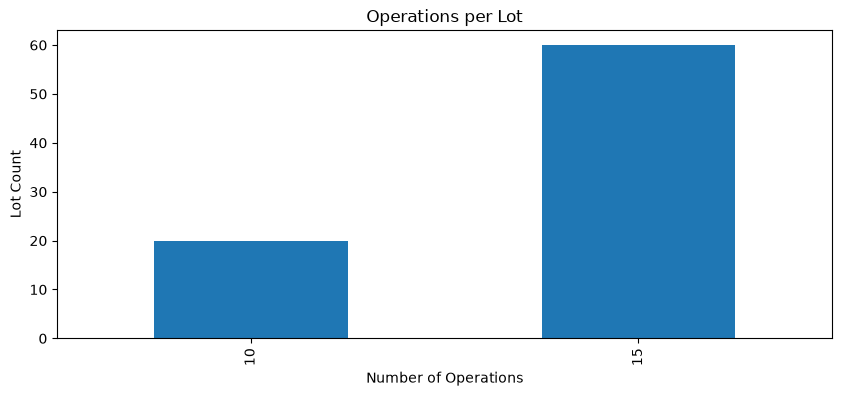

In [6]:
ops_per_lot = ops.groupby('lot_id')['operation_seq'].max()
ops_per_lot.value_counts().sort_index().plot(kind='bar', figsize=(10, 4))
plt.title('Operations per Lot')
plt.xlabel('Number of Operations')
plt.ylabel('Lot Count');

## Tool Usage — Which tools appear most often?

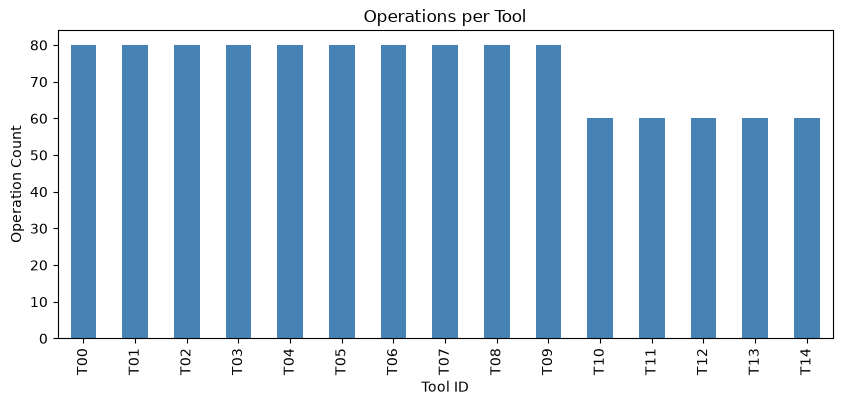

In [7]:
tool_usage = ops['tool_id'].value_counts().sort_index()
tool_usage.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Operations per Tool')
plt.xlabel('Tool ID')
plt.ylabel('Operation Count');

## Run Time Distribution

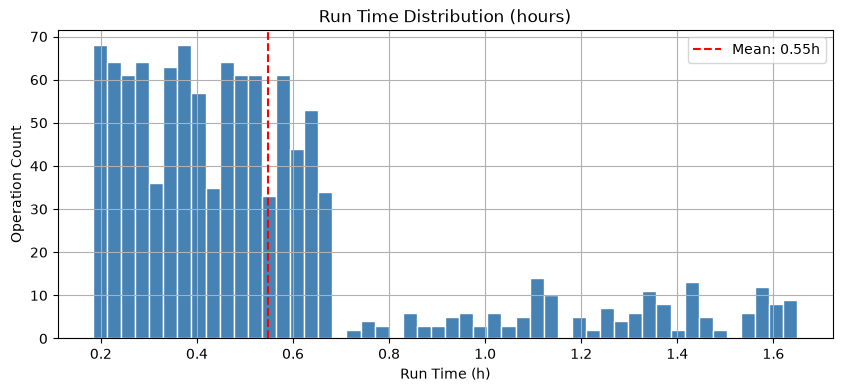

In [8]:
ops['run_time'].hist(bins=50, figsize=(10, 4), color='steelblue', edgecolor='white')
plt.title('Run Time Distribution (hours)')
plt.xlabel('Run Time (h)')
plt.ylabel('Operation Count')
plt.axvline(ops['run_time'].mean(), color='red', linestyle='--', label=f"Mean: {ops['run_time'].mean():.2f}h")
plt.legend();

## Lot Release Schedule

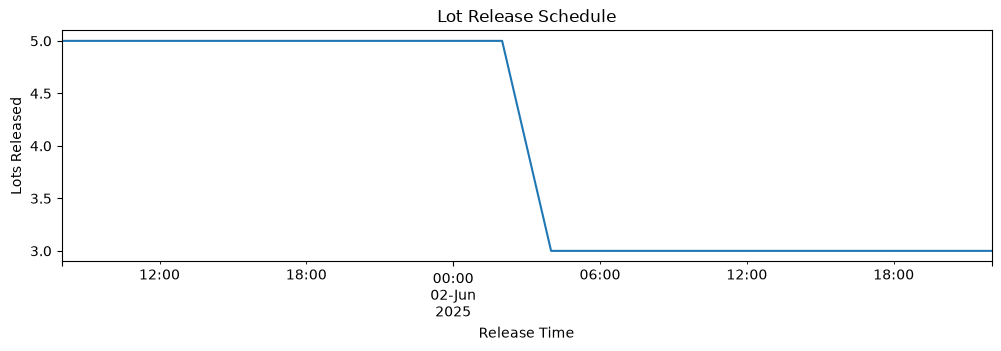

In [9]:
lots['release_ts'] = pd.to_datetime(lots['release_ts'])
lots.set_index('release_ts')['instance_id'].resample('2h').count().plot(figsize=(12, 3))
plt.title('Lot Release Schedule')
plt.xlabel('Release Time')
plt.ylabel('Lots Released');

## Key Takeaways

- Total: **80 lots**, **1,100 operations** across 5 instances
- abz5/abz6: 10 lots × 10 ops = 100 ops each; abz7/abz8/abz9: 20 lots × 15 ops = 300 ops each
- 15 unique tools (T00–T14), grouped into 5 tool groups (TG_00–TG_04)
- Run times range from ~0.3h to ~1.8h, with mean ~1.1h
- Lots are released staggered 2h apart across ~6 days